## NRI Data Check
Access Data from past and current versions (2020,2021,2023,2025)\
Identify and isolate relevant columns, basic exploration, generate summary score for YoY risk index


In [2]:
import pandas as pd
from arcgis.features import FeatureLayer
import urllib3
import warnings

# 1. Suppress SSL Warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.simplefilter("ignore", UserWarning)

def fetch_nri_by_url(service_url, version_label):
    """
    Fetches data directly via REST URL to bypass Item ID retirement issues.
    """
    print(f"Connecting to {version_label}...")
    try:
        # Initialize the layer directly from the URL
        # We set verify_cert=False to stop the SSL noise in restricted environments
        layer = FeatureLayer(service_url)
        
        # Query the data. We use 'out_fields="*"' to get all columns.
        # We also request result_type='standard' to help with the decompression issue.
        query_result = layer.query(where="1=1", out_fields="*", return_geometry=False)
        
        # Convert to DataFrame
        df = query_result.sdf
        
        # Clean up column names (ArcGIS sometimes adds extra prefixes)
        df.columns = [c.upper() for c in df.columns]
        
        print(f"Successfully imported {len(df)} records for {version_label}.")
        return df
    except Exception as e:
        print(f"Failed to fetch {version_label}: {e}")
        return None

# --- REST Service URLs (Updated for 2020-2023 Snapshots) ---
# Note: These URLs point to the persistent FeatureServer endpoints 
# managed by FEMA or the Resilience/Climate Hubs.

urls = {
    "2020_v1_17": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/NRI_Counties_v117/FeatureServer/0",
    "2021_v1_18": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/NRI_Counties_Prod_v1181_view/FeatureServer/0",
    "2023_v1_19": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/National_Risk_Index_Counties_(March_2023)/FeatureServer/0",
    "2025_v1_20": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/National_Risk_Index_Counties/FeatureServer/0"
}

# --- Import Data ---
nri_2020 = fetch_nri_by_url(urls["2020_v1_17"], "NRI 2020 (v1.17)")
nri_2021 = fetch_nri_by_url(urls["2021_v1_18"], "NRI 2021 (v1.18)")
nri_2023 = fetch_nri_by_url(urls["2023_v1_19"], "NRI 2023 (v1.19)")
nri_2025 = fetch_nri_by_url(urls["2025_v1_20"], "NRI 2025 (v1.20)")

Connecting to NRI 2020 (v1.17)...
Successfully imported 3142 records for NRI 2020 (v1.17).
Connecting to NRI 2021 (v1.18)...
Successfully imported 3142 records for NRI 2021 (v1.18).
Connecting to NRI 2023 (v1.19)...
Successfully imported 3231 records for NRI 2023 (v1.19).
Connecting to NRI 2025 (v1.20)...
Successfully imported 3232 records for NRI 2025 (v1.20).


In [39]:
pd.options.display.float_format = '{:,.2f}'.format
print(nri_2020.shape)
nri_2020.iloc[:,0:22].head()

(3142, 353)


,FID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,AREA,RISK_SCORE,RISK_RATNG,RISK_NPCTL,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_NPCTL,EAL_SPCTL,EAL_VALT
0,17,C21149,Kentucky,KY,21,McLean,County,149,21149,9531,...,252.47,8.83,Very Low,39.18,44.17,12.85,Relatively Low,53.72,58.33,"4,781,434.67"
1,29,C21171,Kentucky,KY,21,Monroe,County,171,21171,10963,...,329.37,7.97,Very Low,30.55,35.00,9.76,Very Low,25.02,24.17,"2,443,862.01"
2,34,C21181,Kentucky,KY,21,Nicholas,County,181,21181,7135,...,195.16,6.85,Very Low,19.19,16.67,9.04,Very Low,19.45,10.83,"2,038,813.23"
3,38,C21189,Kentucky,KY,21,Owsley,County,189,21189,4755,...,197.41,7.79,Very Low,28.45,31.67,6.43,Very Low,5.35,1.67,"949,265.86"
4,47,C21207,Kentucky,KY,21,Russell,County,207,21207,17565,...,253.66,10.48,Relatively Low,55.95,63.33,10.05,Very Low,27.56,26.67,"2,620,645.93"


In [4]:
print(nri_2021.shape)
nri_2021.iloc[:,0:22].head()

(3142, 367)


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,AREA,RISK_SCORE,RISK_RATNG,RISK_NPCTL,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_NPCTL,EAL_SPCTL,EAL_VALT
0,3038,C54091,West Virginia,WV,54,Taylor,County,091,54091,16895,...,172.771013,4.639091,Very Low,8.72056,10.909091,6.021184,Very Low,7.256525,23.636364,654450.823934
1,3029,C54073,West Virginia,WV,54,Pleasants,County,073,54073,7605,...,130.122437,5.050999,Very Low,11.107575,23.636364,7.272528,Very Low,13.685551,40.0,1020501.773858
2,3027,C54069,West Virginia,WV,54,Ohio,County,069,54069,44443,...,105.830156,13.029814,Relatively Low,77.307447,96.363636,12.967656,Relatively Low,60.216423,94.545455,4390609.829974
3,3018,C54051,West Virginia,WV,54,Marshall,County,051,54051,33107,...,305.431201,8.071431,Very Low,39.783577,69.090909,9.293991,Very Low,29.471674,61.818182,1863809.738339
4,3007,C54029,West Virginia,WV,54,Hancock,County,029,54029,30676,...,82.609282,6.853396,Very Low,27.084659,50.909091,7.820955,Very Low,17.568428,45.454545,1216549.991751


In [5]:
print(nri_2023.shape)
nri_2023.iloc[:,0:22].head()

(3231, 467)


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB
0,225,C06075,California,CA,06,San Francisco,County,075,06075,873808,...,234.255013,336994912.772555,98.918231,Relatively High,77.586207,99.009595,Relatively High,79.310345,306717285.480768,216666906.626423
1,270,C08047,Colorado,CO,08,Gilpin,County,047,08047,5803,...,151.904533,2032368.243503,14.190264,Very Low,32.8125,18.539152,Very Low,42.1875,2148933.230405,1515490.278917
2,394,C13011,Georgia,GA,13,Banks,County,011,13011,18018,...,236.772855,2647204.063104,19.917276,Very Low,24.528302,18.16775,Very Low,26.415094,2126445.260904,1132438.087473
3,395,C13013,Georgia,GA,13,Barrow,County,013,13013,83288,...,164.577075,7095738.638023,54.692969,Relatively Low,55.974843,52.058186,Relatively Low,61.006289,5761751.546295,3116158.644897
4,400,C13023,Georgia,GA,13,Bleckley,County,023,13023,12537,...,221.343543,2198793.880493,15.908368,Very Low,21.383648,14.48468,Very Low,22.012579,1799524.557198,1151924.279792


In [6]:
print(nri_2025.shape)
nri_2025.iloc[:,0:22].head()

(3232, 467)


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB
0,225,C06075,California,CA,06,San Francisco,County,075,06075,873808,...,234.255013,915983769.771988,99.522901,Very High,99.522901,99.597772,Relatively High,86.206897,853429992.674755,539559891.569997
1,270,C08047,Colorado,CO,08,Gilpin,County,047,08047,5803,...,151.904533,3622102.357588,6.361323,Very Low,6.361323,10.891089,Very Low,18.75,4503801.519584,3903033.55334
2,394,C13011,Georgia,GA,13,Banks,County,011,13011,18018,...,236.772855,5617884.832526,12.40458,Very Low,12.40458,17.079208,Very Low,32.704403,5943369.970484,3549609.943071
3,395,C13013,Georgia,GA,13,Barrow,County,013,13013,83288,...,164.577075,15107820.303437,45.610687,Relatively Low,45.610687,57.054455,Relatively Low,72.327044,18174614.757267,13795365.351176
4,400,C13023,Georgia,GA,13,Bleckley,County,023,13023,12537,...,221.343543,8981662.601893,25.667939,Very Low,25.667939,19.956683,Very Low,37.735849,6599599.390071,2504893.426538


# Columns of interest:
State, county, population, 
bldg value, agricultural value, area, 
risk value (dollar amount), risk score (nat'l percentile ranking), risk rating (category), 
expected annual loss value (dollar amount), expected annual loss score (nat'l %), expected annual loss rating (category), 
social vulnerability score (nat'l %), social vulnerability rating (category),
Community resilience score (nat'l %), community resilience rating (category), community resilience value (index from source data), community risk factor

'STATEABBRV', 'COUNTY', 'POPULATION', 'BUILDVALUE', 'AGRIVALUE', 'AREA', 'RISK_VALUE', 'RISK_SCORE', 'RISK_RATING', 'EAL_VALT', 'EAL_SCORE', 'EAL_RATING', 'SOVI_SCORE', 'SOVI_RATING', 'RESL_SCORE', 'RESL_RATING', 'RESL_VALUE', 'CRF_VALUE'

20-21
'RISK_NPCTL', 'EAL_VALT', 'SOVI_VALUE', 'RESL_VALUE'

There are detailed fields for each disaster type, state level percent ranks, exp annual loss rate (dollars as % of bldgs, pop, agri), adjusted exp ann loss rate for social vulnerability and comm resil

# Note on Scores:
Scores in 2020 and 2021 were 1-100 relative index scores (although not national percentiles), where 2023 and 2025 have values that represent dollar amounts (meant to be an absolute indicator), and scores that are nat'l percentile rating 

Options: To get the absolute score, we could try retroactively calculating 20 and 21 values by using the formula: 
Risk value = total EAL value x (Soc Value / Comm Resil Value)
RISK_VALUE = EAL_VALT x (SOVI_VALUE / RESL_VALUE)
I'd prefer the absolute indicator rather than relative, but it'll have to be reasonably accurate enough. Alternative, use nat'l % as comparison point- depends on the distribution, if uneven, that could be an indicator of the absolute value, just normalized 1-100.

In [13]:
nri_20 = nri_2020[['STATEABBRV', 'COUNTY', 'POPULATION', 'BUILDVALUE', 'AGRIVALUE', 'AREA', 'RISK_SCORE', 'RISK_RATNG', 'RISK_NPCTL', 'EAL_VALT', 'EAL_NPCTL', 'EAL_RATNG', 'SOVI_SCORE', 'SOVI_RATNG', 'SOVI_VALUE', 'RESL_SCORE', 'RESL_RATNG', 'RESL_VALUE']]
nri_20.columns = nri_20.columns.str.lower()
nri_20['risk_value'] = nri_20['eal_valt'] * (nri_20['sovi_value'] / nri_20['resl_value'])
nri_20.head()
# nri_2020.iloc[:,0:50].columns

/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_4551/3394680010.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['risk_value'] = nri_20['eal_valt'] * (nri_20['sovi_value'] / nri_20['resl_value'])


,stateabbrv,county,population,buildvalue,agrivalue,area,risk_score,risk_ratng,risk_npctl,eal_valt,eal_npctl,eal_ratng,sovi_score,sovi_ratng,sovi_value,resl_score,resl_ratng,resl_value,risk_value
0,KY,McLean,9531,863706000.0,190838000.0,252.474539,8.831322,Very Low,39.178867,4781434.67356,53.723743,Relatively Low,32.991723,Relatively Low,-1.36,55.485802,Relatively High,2.77429,-2343933.374538
1,KY,Monroe,10963,937341000.0,102471000.0,329.373322,7.97202,Very Low,30.553787,2443862.01094,25.015913,Very Low,37.564052,Relatively Moderate,-0.2,53.152198,Relatively Moderate,2.65761,-183914.276579
2,KY,Nicholas,7135,578136000.0,25939000.0,195.161193,6.85419,Very Low,19.191598,2038813.2349,19.446213,Very Low,37.721719,Relatively Moderate,-0.16,57.480202,Relatively High,2.87401,-113503.46945
3,KY,Owsley,4755,294889000.0,1294000.0,197.407333,7.788507,Very Low,28.453215,949265.863659,5.346913,Very Low,53.015372,Relatively High,3.72,50.565,Relatively Low,2.52825,1396724.616953
4,KY,Russell,17565,1658507000.0,37513000.0,253.657241,10.48038,Relatively Low,55.951623,2620645.9303,27.562062,Very Low,45.683879,Relatively High,1.86,50.6386,Relatively Low,2.53193,1925172.271887


In [14]:
nri_20['risk_value'].describe()

count              3142.0
mean      -1841657.069736
std        36762126.79879
min     -947545352.466271
25%       -2697671.420473
50%                   0.0
75%        2074742.045181
max      899934487.180887
Name: risk_value, dtype: Float64

In [17]:
nri_23 = nri_2023[['STATEABBRV', 'COUNTY', 'POPULATION', 'BUILDVALUE', 'AGRIVALUE', 'AREA', 'RISK_VALUE', 'RISK_SCORE', 'RISK_RATNG', 'EAL_VALT', 'EAL_SCORE', 'EAL_RATNG', 'SOVI_SCORE', 'SOVI_RATNG', 'RESL_SCORE', 'RESL_RATNG', 'RESL_VALUE', 'CRF_VALUE']]
nri_23.columns = nri_23.columns.str.lower()
nri_23


,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_valt,eal_score,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value
0,CA,San Francisco,873808,154871409399.0,37731586.0,234.255013,336994912.772555,98.918231,Relatively High,306717285.480768,99.009595,Relatively High,43.220001,Relatively Moderate,99.139999,Very High,2.896391,1.098715
1,CO,Gilpin,5803,1602825670.0,260114.0,151.904533,2032368.243503,14.190264,Very Low,2148933.230405,18.539152,Very Low,1.46,Very Low,77.150002,Relatively High,2.701315,0.945757
2,GA,Banks,18018,3412447446.0,194466339.0,236.772855,2647204.063104,19.917276,Very Low,2126445.260904,18.16775,Very Low,51.02,Relatively Moderate,17.190001,Very Low,2.459002,1.244896
3,GA,Barrow,83288,11984393098.0,41245675.0,164.577075,7095738.638023,54.692969,Relatively Low,5761751.546295,52.058186,Relatively Low,52.549999,Relatively Moderate,45.540001,Relatively Moderate,2.57992,1.231525
4,GA,Bleckley,12537,2248881326.0,14224711.0,221.343543,2198793.880493,15.908368,Very Low,1799524.557198,14.48468,Very Low,63.209999,Relatively High,40.290001,Relatively Moderate,2.558459,1.221875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3226,WY,Sublette,8723,3417096880.0,54924025.0,4985.480236,5456759.103902,44.988864,Very Low,5072446.423401,47.539461,Very Low,9.77,Very Low,5.73,Very Low,2.377555,1.075765
3227,WY,Park,29572,6999574188.0,97704296.0,7035.469921,3255887.516466,26.439707,Very Low,3468556.369543,33.178582,Very Low,7.03,Very Low,65.25,Relatively High,2.657005,0.938687
3228,WY,Lincoln,19576,5648705263.0,54890723.0,4135.958239,11558909.992506,69.074133,Relatively Low,10929221.561095,69.452182,Relatively Low,14.54,Very Low,30.01,Relatively Low,2.516999,1.057615
3229,WY,Fremont,39175,8643212130.0,94529804.0,9359.281395,6874912.298088,53.483933,Relatively Low,5738097.595592,51.934386,Relatively Low,72.690002,Relatively High,22.09,Relatively Low,2.483684,1.198117


In [33]:
nri_2023.iloc[:,0:50].columns

Index(['OBJECTID', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'POPULATION', 'BUILDVALUE',
       'AGRIVALUE', 'AREA', 'RISK_VALUE', 'RISK_SCORE', 'RISK_RATNG',
       'RISK_SPCTL', 'EAL_SCORE', 'EAL_RATNG', 'EAL_SPCTL', 'EAL_VALT',
       'EAL_VALB', 'EAL_VALP', 'EAL_VALPE', 'EAL_VALA', 'ALR_VALB', 'ALR_VALP',
       'ALR_VALA', 'ALR_NPCTL', 'ALR_VRA_NPCTL', 'SOVI_SCORE', 'SOVI_RATNG',
       'SOVI_SPCTL', 'RESL_SCORE', 'RESL_RATNG', 'RESL_SPCTL', 'RESL_VALUE',
       'CRF_VALUE', 'AVLN_EVNTS', 'AVLN_AFREQ', 'AVLN_EXP_AREA', 'AVLN_EXPB',
       'AVLN_EXPP', 'AVLN_EXPPE', 'AVLN_EXPT', 'AVLN_HLRB', 'AVLN_HLRP',
       'AVLN_HLRR', 'AVLN_EALB', 'AVLN_EALP'],
      dtype='object')

In [30]:
nri_2020[(nri_2020['STATEABBRV'] == 'FL') & (nri_2020['COUNTY'] == 'DeSoto')].iloc[:,0:22]

,FID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,AREA,RISK_SCORE,RISK_RATNG,RISK_NPCTL,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_NPCTL,EAL_SPCTL,EAL_VALT
478,1400,C12027,Florida,FL,12,DeSoto,County,027,12027,34862,...,637.059208,15.779708,Relatively Moderate,85.646085,53.731343,14.211117,Relatively Low,62.953533,38.80597,6157013.57696


In [29]:
nri_2023[(nri_2023['STATEABBRV'] == 'FL') & (nri_2023['COUNTY'] == 'DeSoto')].iloc[:,0:22]

,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB
0,334,C12027,Florida,FL,12,DeSoto,County,027,12027,33898,...,645.557382,46957763.089975,90.423163,Relatively Moderate,47.761194,86.505726,Relatively Moderate,41.791045,28463944.157504,22445902.830498


In [9]:
print("\nMissing values total 2020")
print(nri_2020.isna().sum().sum())
print("\nMissing values total 2021")
print(nri_2021.isna().sum().sum())
print("\nMissing values total 2023")
print(nri_2023.isna().sum().sum())
print("\nMissing values total 2025")
print(nri_2025.isna().sum().sum())



Missing values total 2020
0

Missing values total 2021
189466

Missing values total 2023
267058

Missing values total 2025
250867


In [11]:
nri_2025.isna().sum().sort_values(ascending=False)

WFIR_EVNTS       3232
ERQK_EVNTS       3232
CFLD_EVNTS       3232
TSUN_RISKV       3167
TSUN_RISKS       3167
                 ... 
HRCN_EALR           0
HRCN_RISKR          0
NRI_ID              0
ISTM_EALR           0
SHAPE__LENGTH       0
Length: 467, dtype: int64

In [42]:
nri_25 = nri_2025[['STATEABBRV', 'COUNTY', 'POPULATION', 'BUILDVALUE', 'AGRIVALUE', 'AREA', 'RISK_VALUE', 'RISK_SCORE', 'RISK_RATNG', 'EAL_VALT', 'EAL_SCORE', 'EAL_RATNG', 'SOVI_SCORE', 'SOVI_RATNG', 'RESL_SCORE', 'RESL_RATNG', 'RESL_VALUE', 'CRF_VALUE']]
nri_25.columns = nri_25.columns.str.lower()
nri_25.head()

,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_valt,eal_score,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value
0,CA,San Francisco,873808,"173,852,174,526.00","42,355,903.00",234.26,"915,983,769.77",99.52,Very High,"853,429,992.67",99.60,Relatively High,48.06,Relatively Moderate,99.65,Very High,2.81,1.07
1,CO,Gilpin,5803,"1,799,265,140.00","291,994.00",151.90,"3,622,102.36",6.36,Very Low,"4,503,801.52",10.89,Very Low,12.75,Very Low,79.29,Relatively High,2.58,0.80
2,GA,Banks,18018,"3,830,670,950.00","218,299,789.00",236.77,"5,617,884.83",12.40,Very Low,"5,943,369.97",17.08,Very Low,24.81,Relatively Low,14.63,Very Low,2.35,0.95
3,GA,Barrow,83288,"13,453,179,051.00","46,300,672.00",164.58,"15,107,820.30",45.61,Relatively Low,"18,174,614.76",57.05,Relatively Low,14.06,Very Low,35.31,Relatively Low,2.43,0.83
4,GA,Bleckley,12537,"2,524,500,231.00","15,968,067.00",221.34,"8,981,662.60",25.67,Very Low,"6,599,599.39",19.96,Very Low,74.30,Relatively High,52.70,Relatively Moderate,2.49,1.36


# To do
- Figure out risk value
- Arrange multi-year df in friendly format
- calculate (or write funtion) for change over time (takes multiple years, difference between max year value and min year)

In [20]:
nri_25.risk_value.describe()

count               3144.0
mean       51500133.487944
std        219202408.27192
min           54920.459871
25%         8825243.722176
50%        16925905.010101
75%        35591427.710126
max      9180158357.595432
Name: risk_value, dtype: Float64

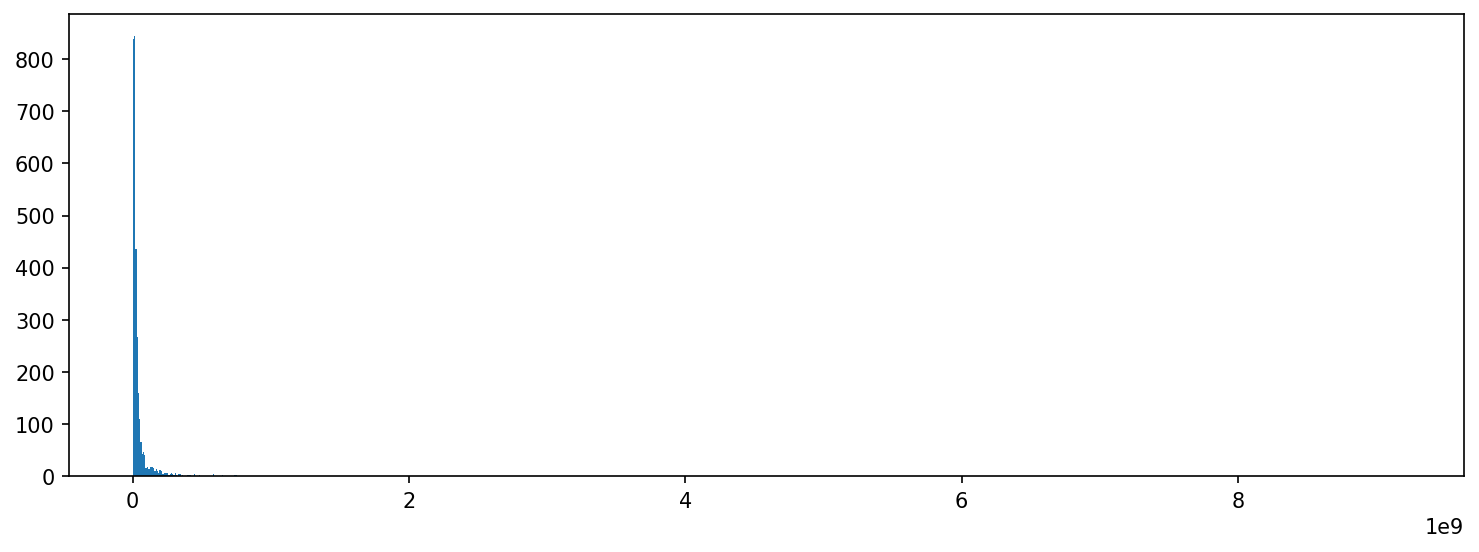

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ymin,ymax = ax.get_ylim() 

ax.hist(nri_25.risk_value, bins=1000)
ax.vlines(x=nri_25.risk_value.mean(),ymin=ymin,ymax=ymax,colors='r',linestyles='--',label='Avg')
plt.show()

In [50]:
# pd.options.display.float_format = '{:,.2f}'.format
#nri_25.risk_value = nri_25.risk_value.round(2)
nri_25.style.format({"risk_value": "{:,}"})
nri_25[nri_25['risk_value'] > 1000000000].sort_values('risk_value',ascending=False)

# nri_25['risk_value' > 1000000000]


,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_valt,eal_score,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value
3053,CA,Los Angeles,10005712,"1,703,724,947,920.00","199,072,663.00","4,797.38","9,180,158,357.60",100.00,Very High,"7,601,846,373.16",100.00,Very High,55.38,Relatively Moderate,13.55,Very Low,2.35,1.21
2854,IL,Cook,5272775,"1,002,575,627,463.00","25,352,865.00","1,651.14","2,957,063,119.42",99.97,Very High,"2,424,304,449.02",99.97,Very High,61.74,Relatively High,73.28,Relatively High,2.55,1.22
2755,TX,Harris,4726200,"838,838,945,279.00","65,130,587.00","1,795.34","2,947,094,007.15",99.94,Very High,"2,217,702,382.78",99.91,Very High,67.94,Relatively High,17.88,Very Low,2.36,1.33
3056,CA,Riverside,2416838,"470,055,458,576.00","1,200,000,752.00","7,376.81","2,304,891,315.00",99.90,Very High,"2,265,637,642.99",99.94,Very High,33.33,Relatively Low,13.04,Very Low,2.34,1.02
3042,AZ,Maricopa,4418836,"854,730,526,869.00","1,556,808,461.00","9,319.14","2,118,483,387.32",99.87,Very High,"2,195,561,910.06",99.88,Very High,27.10,Relatively Low,18.03,Very Low,2.37,0.96
3057,CA,San Bernardino,2179979,"423,886,169,656.00","481,450,205.00","20,308.30","2,104,012,031.89",99.84,Very High,"2,075,099,788.96",99.85,Very High,33.21,Relatively Low,20.07,Relatively Low,2.37,1.01
2420,CA,Orange,3183647,"606,399,782,637.00","106,232,076.00",959.30,"1,822,511,759.81",99.81,Very High,"1,926,466,710.37",99.78,Very High,24.94,Relatively Low,16.32,Very Low,2.36,0.95
2808,CA,Alameda,1678284,"373,356,820,346.00","59,439,333.00",829.50,"1,776,525,270.88",99.78,Very High,"1,884,810,318.99",99.75,Very High,27.48,Relatively Low,91.16,Very High,2.63,0.94
2819,CA,Santa Clara,1934625,"428,353,306,701.00","399,381,703.00","1,317.22","1,686,687,111.82",99.75,Very High,"1,965,273,927.89",99.81,Very High,17.24,Very Low,72.61,Relatively High,2.55,0.86
3058,CA,San Diego,3295981,"638,825,464,234.00","1,070,494,224.00","4,571.49","1,462,271,163.08",99.71,Very High,"1,539,181,273.08",99.69,Very High,24.81,Relatively Low,8.30,Very Low,2.30,0.95


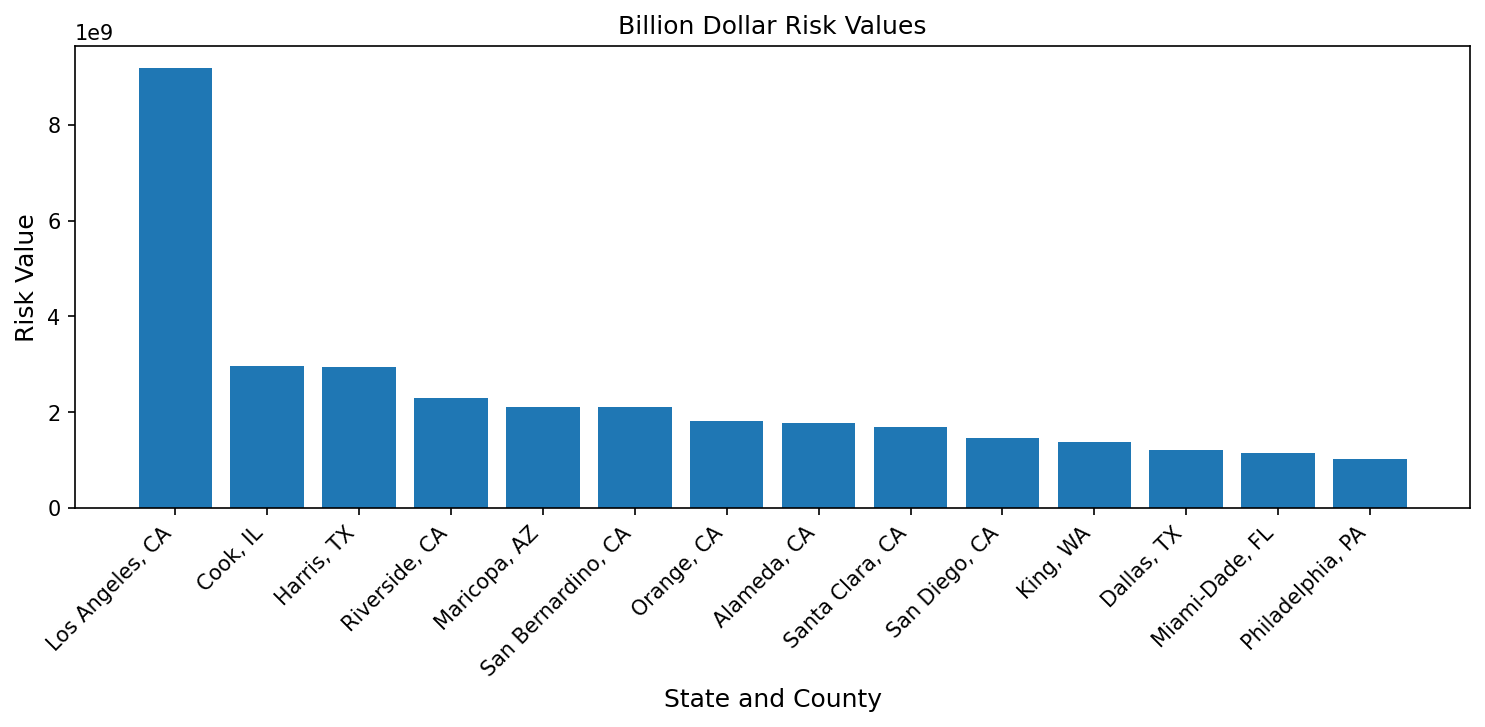

In [64]:
bil_25 = nri_25[nri_25['risk_value'] > 1000000000].sort_values('risk_value',ascending=False)
bil_25['county_state'] = bil_25.county + ', ' + bil_25.stateabbrv
# bil_25.risk_value.plot(kind='bar')

plt.figure(figsize=(12, 4), dpi=150)
plt.bar(bil_25['county_state'],bil_25.risk_value, linewidth=2)
plt.xticks(rotation=45,ha='right')
plt.title("Billion Dollar Risk Values")
plt.ylabel("Risk Value", fontsize=12)
plt.xlabel("State and County", fontsize=12)
plt.show()

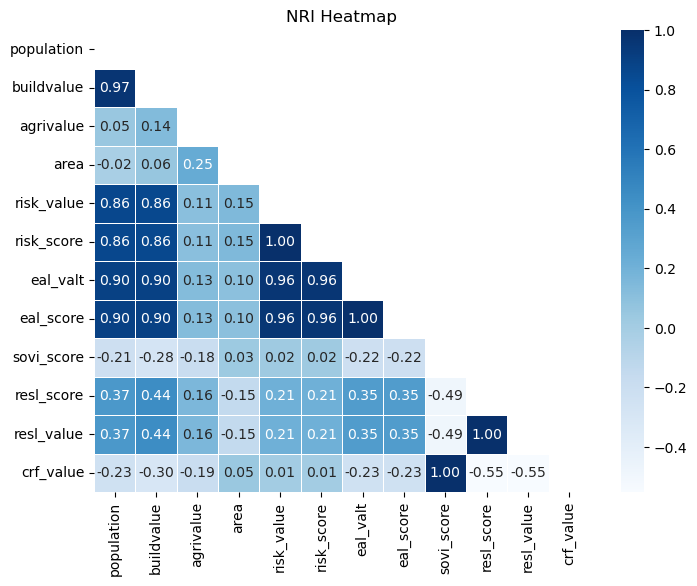

In [51]:
import numpy as np

correlation_matrix = nri_25.corr(method='spearman',numeric_only=True) # numeric_only=True to handle non-numeric columns
correlation_matrix

mask = np.ones_like(correlation_matrix, dtype=bool)
mask = np.triu(mask)
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, mask=mask)
plt.title('NRI Heatmap')
plt.show()